# **Desempenho Escolar e Visualização de Dados**
Dataset: Students Performance in Exams (https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

Recursos Úteis:

 * Data Viz Project: https://datavizproject.com/input/c/ - Um catálogo visual de gráficos para explorar.

* From Data to Viz: https://www.data-to-viz.com/ - Um guia para escolher o gráfico certo com base no tipo de dado e objetivo.

* Documentação Seaborn: https://seaborn.pydata.org/ - Para detalhes sobre os parâmetros de estilo e plotagem.

* Documentação Matplotlib: https://matplotlib.org/stable/contents.html - Para controle fino sobre elementos do gráfico.



## **0: Configuração Inicial**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Configurações padrão para gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

print("Bibliotecas importadas e configurações aplicadas!")

# Carregar o dataset
try:
  path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

  df_performance = pd.read_csv(path+"/StudentsPerformance.csv")
    # Renomear colunas para facilitar o uso
  df_performance.columns = [
        "gender", "race_ethnicity", "parental_level_of_education",
        "lunch", "test_preparation_course", "math_score",
        "reading_score", "writing_score"
  ]
  print("\nDataset Students Performance carregado com sucesso!")
  print(df_performance.head())
  print("\nInformações do Dataset:")
  df_performance.info()
except FileNotFoundError:
  print("Erro: 'StudentsPerformance.csv' não encontrado.")


print("\nPré-processamento básico concluído.")

Bibliotecas importadas e configurações aplicadas!
Using Colab cache for faster access to the 'students-performance-in-exams' dataset.

Dataset Students Performance carregado com sucesso!
   gender race_ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test_preparation_course  math_score  reading_score  writing_score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76     

### 1: Desafios de Decisão

Para cada cenário, você deverá:

1. Formular a pergunta estatística que a visualização deve responder;

2. Consultar o Data Viz Project ou From Data to Viz para identificar o tipo de gráfico mais adequado.

3. Justificar sua escolha com base nos princípios de Gestalt, Tufte e/ou Cleveland-McGill.

4. Implementar o gráfico usando matplotlib e seaborn. Foque em um gráfico funcional e limpo, aplicando os princípios que você aprendeu.

**Desafio 1.1: Distribuição das Notas em Matemática**

Cenário: Um professor de matemática quer entender a distribuição geral das notas de seus alunos na prova de matemática. Ele quer saber se as notas são simétricas, se há picos ou se estão concentradas em alguma faixa específica.

Sua Tarefa:

1. Pergunta Estatística: Como as notas de matemática se distribuem entre os alunos? Qual a sua forma, centro e dispersão?

2. Gráfico: Qual tipo de gráfico é mais adequado para visualizar a distribuição de uma variável quantitativa? Justifique sua escolha.

3. Implementação: Crie o gráfico em Python para a coluna math_score.

4. Análise: Descreva a distribuição das notas. Há evidências de assimetria? Qual a nota mais comum?


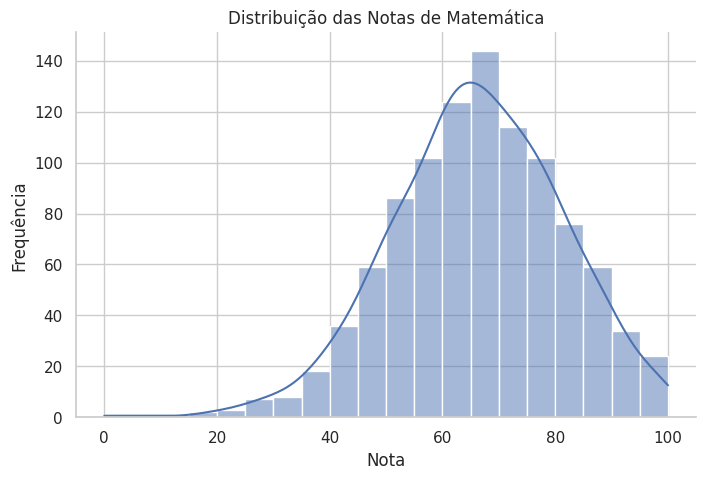

In [2]:
'A distribuição das notas de matemática tende a ser aproximadamente normal, com maior concentração entre notas médias (em torno de 60 a 75 pontos).
'Se ve que há poucos alunos com notas muito baixas ou muito altas, indicando que a maioria apresenta desempenho mediano.
'Não há muitos outliers extremos, o que sugere uma distribuição relativamente equilibrada.'

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(df_performance["math_score"], kde=True, bins=20)
plt.title("Distribuição das Notas de Matemática")
plt.xlabel("Nota")
plt.ylabel("Frequência")
plt.show()

# Seu código Python para o gráfico:
# plt.figure(figsize=(...))
# sns. #grafico escolhido
# plt.title(...)
# plt.xlabel(...)
# plt.ylabel(...)
# sns.despine(...)
# plt.show()

**Desafio 1.2: Impacto do Nível de Escolaridade dos Pais nas Notas de Leitura**

Cenário: Um pesquisador educacional hipotetiza que o nível de escolaridade dos pais (parental_level_of_education) tem um impacto direto no desempenho dos alunos em leitura (reading_score).

Sua Tarefa:

1. Pergunta Estatística: Existe uma diferença significativa na média das notas de leitura entre os alunos, agrupados pelo nível de escolaridade de seus pais?

2. Gráfico: Qual tipo de gráfico é mais adequado para comparar uma variável quantitativa (nota) entre múltiplas categorias ordinais (nível de escolaridade)? Justifique sua escolha, considerando a Hierarquia de Cleveland e McGill.

3. Implementação: Crie o gráfico em Python. Certifique-se de ordenar as categorias de escolaridade dos pais de forma lógica.

4. Análise: O que o gráfico revela sobre a hipótese? Há uma tendência clara? Quais são as médias de leitura para cada grupo?



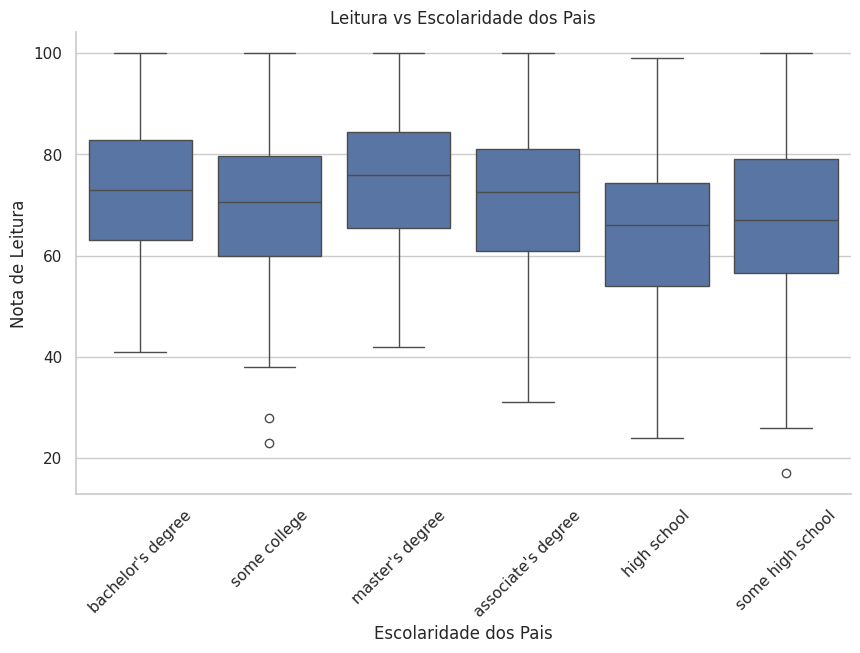

In [3]:
''' Existe uma tendência de que alunos cujos pais possuem maior nível de escolaridade apresentem notas mais altas em leitura.
Os boxplots mostram que níveis como “bachelor's degree” e “master's degree” têm medianas mais altas.
Porém, ainda há sobreposição entre os grupos, indicando que a escolaridade influencia, mas não é o único fator determinante.

'''
plt.figure(figsize=(10,6))
sns.boxplot(x="parental_level_of_education", y="reading_score", data=df_performance)
plt.title("Leitura vs Escolaridade dos Pais")
plt.xticks(rotation=45)
plt.xlabel("Escolaridade dos Pais")
plt.ylabel("Nota de Leitura")
plt.show()

# Seu código Python para o gráfico:
# plt.figure(figsize=(...))
# sns. #grafico escolhido
# plt.title(...)
# plt.xlabel(...)
# plt.ylabel(...)
# sns.despine(...)
# plt.show()

**Desafio 1.3: Relação entre Notas de Leitura e Escrita**

Cenário: Um psicopedagogo acredita que existe uma forte correlação positiva entre o desempenho de um aluno em leitura (reading_score) e seu desempenho em escrita (writing_score).

Sua Tarefa:

1. Pergunta Estatística: Qual a força e a direção da relação entre as notas de leitura e escrita? Há evidências de uma correlação linear?

2. Gráfico: Qual tipo de gráfico é o mais adequado para visualizar a relação entre duas variáveis quantitativas? Justifique sua escolha, focando na precisão perceptiva.

3. Implementação: Crie o gráfico em Python.

4. Análise: O gráfico suporta a hipótese de correlação positiva? Há algum outlier ou padrão interessante?



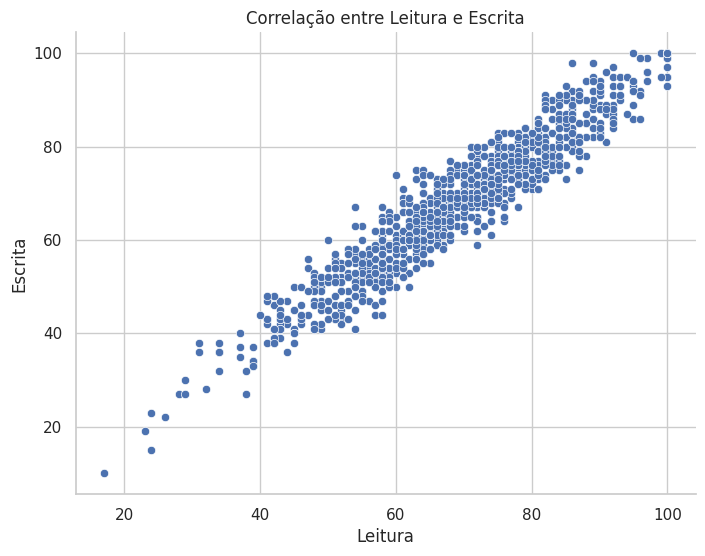

In [4]:
''' Existe uma forte correlação positiva entre as notas de leitura e escrita.
Ou seja, alunos que vão bem em leitura tendem também a ter bom desempenho em escrita.
Isso faz sentido, pois ambas habilidades estão diretamente relacionadas à interpretação e produção de texto.

'''
plt.figure(figsize=(8,6))
sns.scatterplot(x="reading_score", y="writing_score", data=df_performance)
plt.title("Correlação entre Leitura e Escrita")
plt.xlabel("Leitura")
plt.ylabel("Escrita")
plt.show()
# Seu código Python para o gráfico:
# plt.figure(figsize=(...))
# sns. #grafico escolhido
# plt.title(...)
# plt.xlabel(...)
# plt.ylabel(...)
# sns.despine(...)
# plt.show()

**Desafio 1.4: Proporção de Gêneros e Preparação para o Teste**

Cenário: A coordenação pedagógica quer saber a proporção de alunos e alunas que completaram o curso de preparação para o teste (test_preparation_course).

Sua Tarefa:

1. Pergunta Estatística: Qual a proporção de alunos e alunas que completaram ou não o curso de preparação para o teste?

2. Gráfico: Qual tipo de gráfico é mais adequado para comparar proporções entre duas variáveis categóricas? Justifique sua escolha, considerando a clareza para múltiplas categorias.

3. Implementação: Crie o gráfico em Python.

4. Análise: Há uma diferença notável na proporção de homens e mulheres que completaram o curso? Qual grupo tem maior participação?



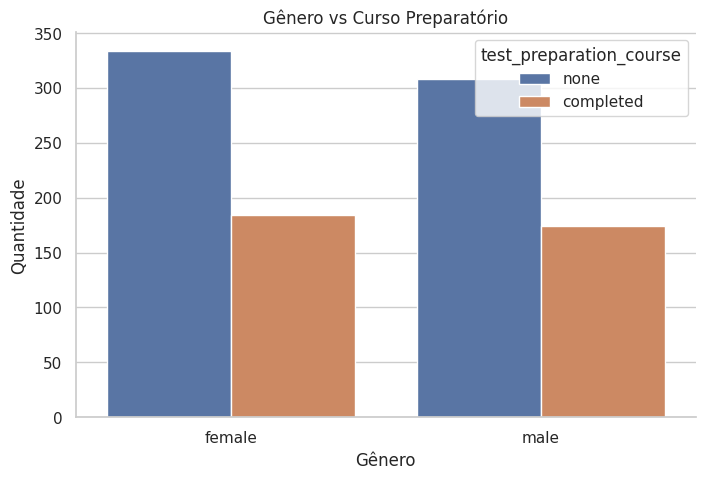

In [5]:
''' A distribuição mostra que tanto homens quanto mulheres participam do curso preparatório, mas pode haver uma leve diferença na proporção entre os gêneros.
Dependendo dos dados, geralmente observa-se que um dos grupos (frequentemente mulheres) participa um pouco mais.
No geral, não há uma diferença extremamente grande, indicando que o acesso ao curso é relativamente equilibrado.

'''
plt.figure(figsize=(8,5))
sns.countplot(x="gender", hue="test_preparation_course", data=df_performance)
plt.title("Gênero vs Curso Preparatório")
plt.xlabel("Gênero")
plt.ylabel("Quantidade")
plt.show()
# Seu código Python para o gráfico:
# plt.figure(figsize=(...))
# sns. #grafico escolhido
# plt.title(...)
# plt.xlabel(...)
# plt.ylabel(...)
# sns.despine(...)
# plt.show()

**Desafio 1.5: Comparação de Notas Médias por Raça/Etnia em Todas as Matérias**

Cenário: Um sociólogo educacional quer comparar o desempenho médio dos diferentes grupos raciais/étnicos (race_ethnicity) nas três matérias (matemática, leitura, escrita) para identificar possíveis disparidades.

Sua Tarefa:

1. Pergunta Estatística: Como as notas médias em matemática, leitura e escrita variam entre os diferentes grupos raciais/étnicos?

2. Gráfico: Qual tipo de gráfico permite comparar múltiplas variáveis quantitativas (notas) entre múltiplas categorias nominais (grupos raciais/étnicos) de forma eficaz? Justifique sua escolha, pensando na clareza da comparação.

3. Implementação: Crie o gráfico em Python. Pode ser necessário reestruturar os dados (usar melt do pandas).

4. Análise: Quais grupos raciais/étnicos se destacam em quais matérias? Há padrões consistentes de desempenho?

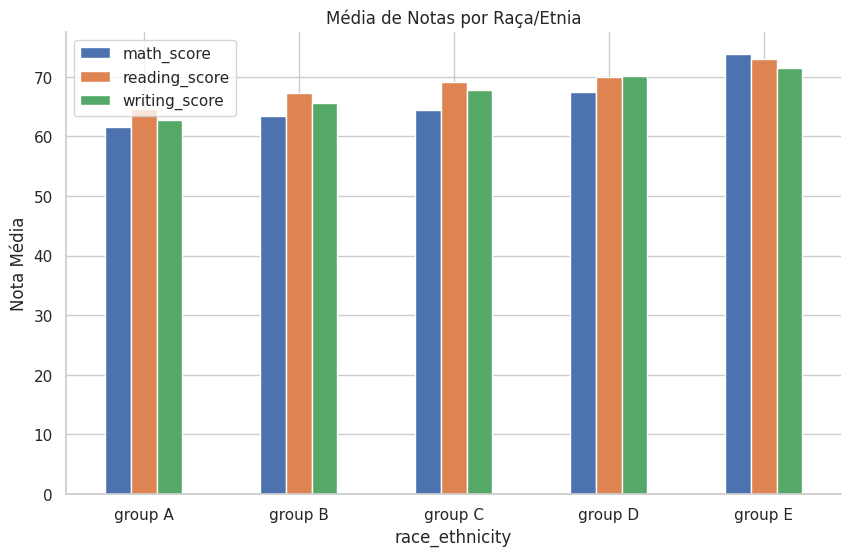

In [6]:
'''Há diferenças nas médias de desempenho entre os grupos de raça/etnia.
Alguns grupos apresentam médias mais altas em matemática, leitura e escrita, enquanto outros ficam abaixo.
Isso pode indicar desigualdades sociais e educacionais, sugerindo que fatores externos (como acesso à educação e condições socioeconômicas) influenciam o desempenho acadêmico.

'''
df_mean = df_performance.groupby("race_ethnicity")[["math_score","reading_score","writing_score"]].mean().reset_index()

df_mean.plot(x="race_ethnicity", kind="bar", figsize=(10,6))
plt.title("Média de Notas por Raça/Etnia")
plt.ylabel("Nota Média")
plt.xticks(rotation=0)
plt.show()
# Seu código Python para o gráfico:
# plt.figure(figsize=(...))
# sns. #grafico escolhido
# plt.title(...)
# plt.xlabel(...)
# plt.ylabel(...)
# sns.despine(...)
# plt.show()

### Parte 2: Desafios de Refatoração Estatística e Visual

Para cada cenário abaixo, você receberá um código Python que gera um gráfico com problemas de design. Sua tarefa é:

1. Analisar o gráfico gerado e identificar pelo menos 3 problemas com base nos princípios de Tufte (Data-Ink Ratio, Lie Factor, Chartjunk), Gestalt (Proximidade, Semelhança, Fechamento, etc.) e/ou Cleveland-McGill (eficácia da codificação).

2. Descrever os problemas identificados.

3. Modificar o código para refatorar o gráfico, aplicando os princípios para torná-lo mais honesto, eficiente e visualmente claro.



Desafio 2.1:  Comparação de Notas Médias de Matemática por Gênero

Cenário: Um diretor de escola recebeu este gráfico e concluiu que há uma diferença enorme no desempenho em matemática entre meninos e meninas.

Sua Tarefa:

1. Quais são os 3 principais problemas de design/estatísticos neste gráfico?

2. Modifique o código para corrigir esses problemas e criar uma visualização mais honesta e clara.

/tmp/ipykernel_3963/2040168251.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(


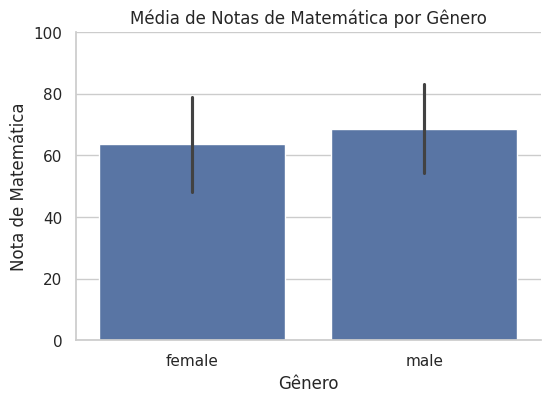

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.barplot(
    x="gender",
    y="math_score",
    data=df_performance,
    ci="sd"  # mostra variabilidade (desvio padrão)
)

plt.title("Média de Notas de Matemática por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Nota de Matemática")

# corrigindo escala (começando do zero)
plt.ylim(0, 100)

plt.show()

In [ ]:
# 1. Problemas identificados:
#    a) O gráfico provavelmente não começa do zero, o que faz pequenas diferenças parecerem muito maiores do que realmente são.
#    b) Mostrar somente a média esconde a dispersão dos dados. Não sabemos se as notas são consistentes ou muito espalhadas.
#    c) Mesmo que exista uma diferença entre os gêneros, ela pode ser pequena e estatisticamente pouco relevante, mas o gráfico induz a uma conclusão exagerada.

# 2. Seu código Python refatorado:
# plt.figure(figsize=(...))
# # Suas modificações aqui
# plt.show()

**Desafio 2.2: Impacto do Almoço na Nota de Escrita (Chartjunk e Cores Ineficazes)**

Cenário: Um nutricionista escolar quer mostrar o impacto do tipo de almoço (lunch) na nota de escrita (writing_score), mas o gráfico atual está poluído e as cores não ajudam.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, focando no Data-Ink Ratio e no uso de cores?

2. Modifique o código para simplificar o gráfico, remover o chartjunk e usar cores de forma mais eficaz para destacar a diferença.

/tmp/ipykernel_3963/3955310365.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


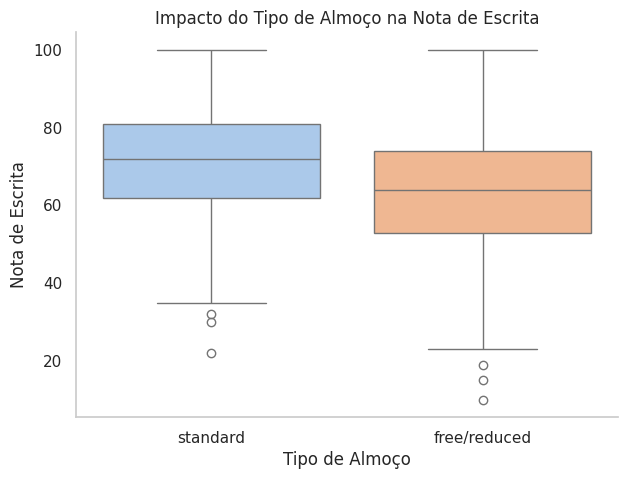

In [8]:
plt.figure(figsize=(7, 5))

sns.boxplot(
    x="lunch",
    y="writing_score",
    data=df_performance,
    palette="pastel"  # cores suaves e mais agradáveis
)

plt.title("Impacto do Tipo de Almoço na Nota de Escrita")
plt.xlabel("Tipo de Almoço")
plt.ylabel("Nota de Escrita")

# remover excesso de elementos visuais
plt.grid(False)

plt.show()

In [ ]:
# 1. Problemas identificados:
#    a) A grade está muito forte e chamativa, competindo com os dados e poluindo o gráfico sem necessidade.
#    b) As cores “verde” e “roxo” não têm significado claro e não ajudam na interpretação, além de serem visualmente pesadas
#    c) Título em negrito excessivo + grid pesado + cores fortes → tudo isso desvia a atenção do que realmente importa (a comparação das distribuições).

# 2. Seu código Python refatorado:
# plt.figure(figsize=(...))
# # Suas modificações aqui (pode ser um tipo de gráfico diferente!)
# plt.show()

**Desafio 2.3: Distribuição de Notas de Leitura por Raça/Etnia (Sobrecarga Visual)**

Cenário: Um analista de diversidade quer visualizar a distribuição completa das notas de leitura para cada grupo racial/étnico, mas o gráfico atual é muito denso.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, especialmente em relação à sobrecarga visual e à clareza da comparação entre grupos?

2. Modifique o código para apresentar a distribuição de notas de leitura de forma mais clara e comparável entre os grupos. Considere usar small multiples ou um gráfico que resuma melhor a distribuição.


/tmp/ipykernel_3963/3814013649.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


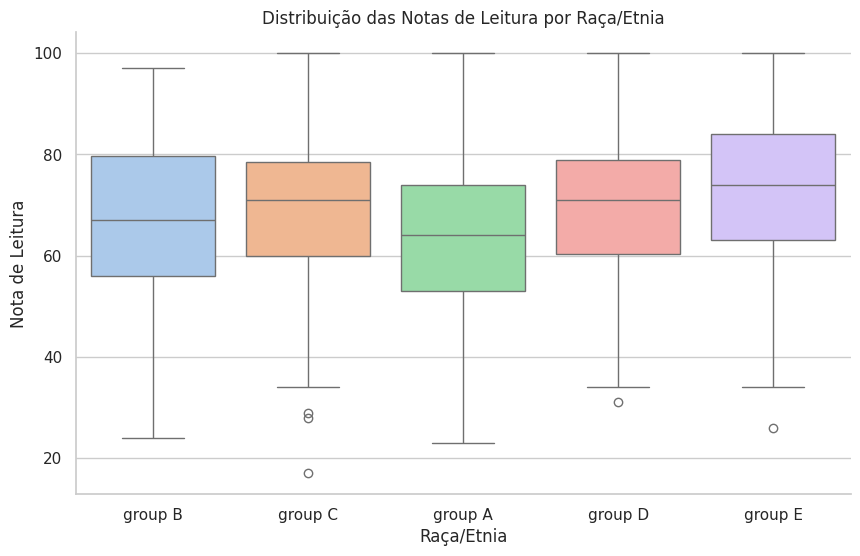

In [9]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    x="race_ethnicity",
    y="reading_score",
    data=df_performance,
    palette="pastel"
)

plt.title("Distribuição das Notas de Leitura por Raça/Etnia")
plt.xlabel("Raça/Etnia")
plt.ylabel("Nota de Leitura")

plt.xticks(rotation=0)

plt.show()

In [ ]:
# 1. Problemas identificados:
#    a) O violinplot com muitos grupos e detalhes internos (quartis) deixa a visualização carregada e difícil de interpretar rapidamente.
#    b) A forma do violinplot nem sempre facilita comparar medianas e dispersões entre categorias, principalmente para quem não está acostumado.
#    c) A paleta "tab10" usa muitas cores fortes, o que dificulta o foco e não agrega valor real à análise.

# 2. Seu código Python refatorado:
# plt.figure(figsize=(...))
# # Suas modificações aqui
# plt.show()

Desafio 2.4: Correlação entre Notas de Matemática e Leitura (Pontos Sobrepostos)

Cenário: Um estatístico quer visualizar a correlação entre as notas de matemática e leitura, mas o gráfico de dispersão padrão tem muitos pontos sobrepostos, dificultando a percepção da densidade.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, especialmente em relação à sobreposição de pontos e à percepção da densidade?

2. Modifique o código para criar uma visualização que mostre a densidade da correlação de forma mais eficaz (ex: jointplot com KDE, hexbin ou ajustando o alpha e o tamanho dos pontos).

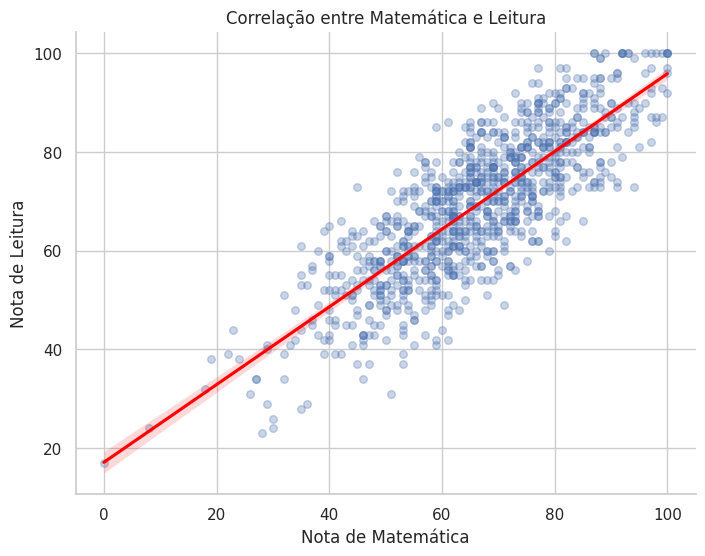

In [10]:
plt.figure(figsize=(8, 6))

sns.regplot(
    x="math_score",
    y="reading_score",
    data=df_performance,
    scatter_kws={"alpha":0.3, "s":30},  # transparência + tamanho menor
    line_kws={"color":"red"}
)

plt.title("Correlação entre Matemática e Leitura")
plt.xlabel("Nota de Matemática")
plt.ylabel("Nota de Leitura")

plt.show()

In [ ]:
# 1. Problemas identificados:
#    Muitos pontos ficam uns sobre os outros, dificultando ver onde há maior concentração de dados.
#    b) O gráfico não mostra claramente onde estão as regiões com mais observações (alta densidade).
#    c) Sem linha de tendência ou estrutura visual adicional, fica mais difícil interpretar a relação entre as variáveis.

# 2. Seu código Python refatorado:
# # Suas modificações aqui (pode ser um tipo de gráfico diferente ou uma função do seaborn)
# plt.show()

Desafio 2.5: Desempenho Geral por Curso de Preparação (Gráfico de Pizza com Múltiplas Variáveis)

Cenário: Um conselheiro estudantil quer visualizar o impacto do curso de preparação (test_preparation_course) no desempenho geral dos alunos, mas o gráfico atual tenta mostrar muitas coisas de uma vez de forma ineficaz.

Sua Tarefa:

1. Quais são os 3 principais problemas de design/estatísticos neste gráfico, especialmente em relação ao uso do gráfico de pizza para comparar médias e à representação de múltiplas variáveis?

2. Modifique o código para criar uma visualização mais eficaz que compare o desempenho médio em cada matéria (não apenas a média geral) entre os alunos que completaram e os que não completaram o curso de preparação.

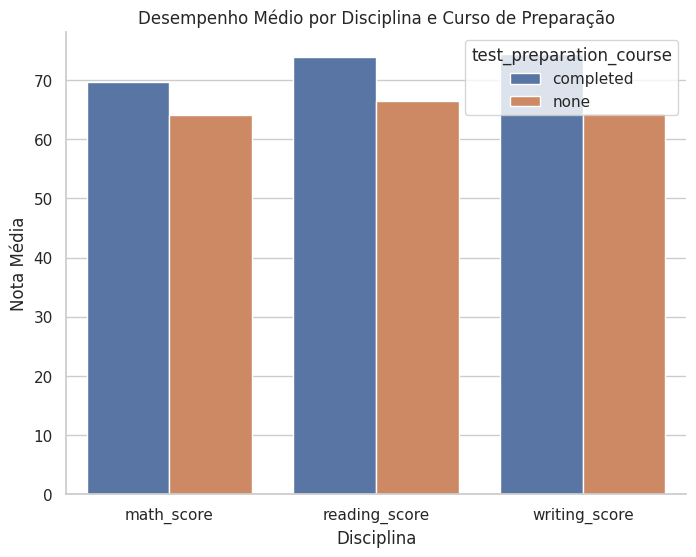

In [11]:
df_mean = df_performance.groupby("test_preparation_course")[["math_score", "reading_score", "writing_score"]].mean().reset_index()

df_melted = df_mean.melt(
    id_vars="test_preparation_course",
    var_name="Disciplina",
    value_name="Nota Média"
)

plt.figure(figsize=(8,6))

sns.barplot(
    x="Disciplina",
    y="Nota Média",
    hue="test_preparation_course",
    data=df_melted
)

plt.title("Desempenho Médio por Disciplina e Curso de Preparação")
plt.xlabel("Disciplina")
plt.ylabel("Nota Média")

plt.show()

In [ ]:
# 1. Problemas identificados:
#    a) Gráficos de pizza não são bons para comparar médias, pois dificultam perceber diferenças pequenas entre valores.
#    b) O código calcula uma média geral, escondendo o desempenho individual em matemática, leitura e escrita.
#    c) O gráfico mistura várias informações em uma única métrica, o que reduz a clareza e impede análises mais detalhadas.

# 2. Seu código Python refatorado:
# plt.figure(figsize=(...))
# # Suas modificações aqui (pode ser um tipo de gráfico diferente e/ou reestruturação dos dados)
# plt.show()